# Bunny graph diffusion


<div class="note"><span class="note-t">TL;DR</span>
<p>We scale the small graph walk's edge-local <code>PSWAP</code> rule up to diffusion on the Stanford bunny's mesh connectivity. Torx supplies the sampled full-graph result, while NumPy supplies the ordered-sweep mean and exact graph-diffusion references.</p>
</div>

In this tutorial, we diffuse a probability distribution on the connectivity graph induced by the Stanford bunny mesh.

We map each unweighted mesh edge to one `PSWAP` gate. A single excitation starts at one ear vertex, and $x_i(t)$ is the probability that it occupies vertex $i$ after averaging repeated one-hot runs.

The combinatorial graph Laplacian $L = D - A$ splits into one symmetric two-node term per edge. An ordered layer of `PSWAP` gates approximates the simultaneous graph evolution, and repeating that layer moves probability through the connectivity graph.

This construction does not model physical surface heat. It ignores edge lengths, triangle angles, vertex areas, and a mesh mass matrix.

We build the full Torx circuit, compare its multi-seed sample mean with the deterministic mean of the same ordered sweep and a NumPy exact reference, then check the same primitive on a closed 32-vertex patch.

This is the mesh-scale version of [notebook 02](02_random_walks_on_graphs.ipynb): the same `PSWAP`-per-edge primitive, now on a few hundred vertices.


## Setup

First we put the local `helpers` directory on the import path, then import Torx and NumPy.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
# Put shared notebook helpers on the import path.
sys.path.insert(0, str(HELPER_DIR))

In [2]:
from collections import deque

import numpy as np

from torx.psc import DiscretePCircuit, PSWAP

The computation is split across the notebook and shared helpers.

<details class="tx-disclosure"><summary>What runs where?</summary><ul><li>Torx executes the repeated <code>PSWAP</code> circuits and returns sampled occupancies.</li><li>Notebook code exposes the full circuit and reports sampling error, splitting bias, and total error.</li><li><code>examples/helpers/_graph_diffusion.py</code> provides NumPy references and Torx sampling wrappers, while <code>examples/helpers/_stanford_bunny.py</code> loads, decimates, reconnects, and plots the mesh.</li><li>The offline mesh is <code>examples/assets/stanford_bunny/bun_zipper_res3.ply</code>.</li></ul></details>

In [3]:
from _notebook_paths import figure_dir
from _notebook_style import apply_notebook_style, make_savefig
from _graph_diffusion import (
    _edge_swap_probability as shared_edge_swap_probability,
    build_graph_generator,
    ordered_pswap_product_formula_mean,
    reference_heat_flow,
    sample_pswap_product_formula,
    sample_pswap_product_formula_multiseed,
)
from _stanford_bunny import (
    decimate_mesh,
    largest_connected_mesh,
    load_ascii_ply,
    mesh_edges,
    save_torx_reference_figure,
    visible_source_vertex,
)

The plotting style and output path remain in the plotting helpers. Mesh preprocessing is imported from the mesh helper above.

In [4]:
import _plots_sampling as P_samp
import _plots_schematics as P_sch

apply_notebook_style()
FIGURE_DIR = figure_dir(ROOT)
savefig = make_savefig(FIGURE_DIR)
MESH_PATH = ROOT / "assets" / "stanford_bunny" / "bun_zipper_res3.ply"
assert MESH_PATH.exists(), MESH_PATH

## Graph connectivity, the Laplacian, and one swap per edge

A triangle mesh induces a graph $G = (V, E)$: each vertex is a [pbit](01_introduction_to_parametrised_stochastic_circuits.ipynb), and each triangle side contributes an unweighted edge. The **combinatorial graph Laplacian** $L = D - A$, built from the degree matrix $D$ and adjacency matrix $A$, defines

$$
\dot x = -Lx,
\qquad
x(t) = e^{-Lt}x(0).
$$

Probability flows between adjacent vertices. This is the master equation from [notebook 02](02_random_walks_on_graphs.ipynb) with generator $Q=-L$.

The Laplacian splits into one symmetric two-node block per edge, $L=\sum_{(i,j)\in E}L_{ij}$. [Lie-Trotter splitting](#ref-trotter-1959) rewrites the exact propagator as the limit of ordered per-edge products:

$$
x(t) = \lim_{N\to\infty}\Bigl(\underbrace{\textstyle\prod_{(i,j)\in E}e^{\Delta t Q_{ij}}}_{\vphantom{\big|}\text{ordered per-edge sweep}}\Bigr)^N x(0),
\qquad
\Delta t=t/N.
$$

At finite $N$, Torx executes each product as a sequential sweep over the edge list. Each factor $e^{\Delta t Q_{ij}}$ is one `PSWAP` with $p=\tfrac12(1-e^{-2\Delta t})$ for this unit-rate graph. Overlapping edge blocks do not commute, so the ordered product has splitting bias at finite $N$.

Torx never forms $e^{-Lt}$. NumPy computes the exact eigensolution and the deterministic ordered-sweep mean used below for comparison.


## Diffusion on the bunny connectivity graph

All probability starts on one ear vertex and spreads through graph edges.

We load the `bun_zipper_res3` reconstruction from the [Stanford bunny dataset](#ref-stanford-bunny), keep its largest connected component, then coarsen it with `decimate_mesh` from `examples/helpers/_stanford_bunny.py`. The decimator snaps vertices to a uniform 3-D grid, replaces occupied cells with centroids, remaps faces, and drops collapsed triangles. This preprocessing determines the 450-vertex, 1,352-edge graph used below.

Torx samples the full graph at $t=1.5$. The $t=10$ and $t=40$ panels are expensive **NumPy exact references**, not Torx results.

The same-time Torx and NumPy comparison uses one shared absolute color scale. The time progression uses per-panel peak normalization, with each raw peak printed in its title.


In [5]:
raw_vertices, raw_faces = load_ascii_ply(MESH_PATH)
full_vertices, full_faces = largest_connected_mesh(raw_vertices, raw_faces)

# Grid-snap the mesh to define the smaller connectivity graph used below.
TARGET_VERTICES = 400
vertices, faces = decimate_mesh(full_vertices, full_faces, TARGET_VERTICES)
vertices, faces = largest_connected_mesh(vertices, faces)
edges = mesh_edges(faces)
source = visible_source_vertex(vertices)



In [6]:
assert len(full_vertices) == 1_887  # full largest connected component
assert 250 <= len(vertices) <= 600  # coarsened, still bunny-shaped
assert len(edges) >= len(vertices)  # connected graph
# TORX_STEPS is tuned to this realized coarse graph size.
# Changing the mesh or target size requires retuning the step count.



In [7]:
print(f"full mesh:    {len(full_vertices)} vertices")
print(f"coarse mesh:  {len(vertices)} vertices, {len(faces)} faces, {len(edges)} edges")
print(f"source:       vertex {int(source)}")

full mesh:    1887 vertices
coarse mesh:  450 vertices, 932 faces, 1352 edges
source:       vertex 239


In [8]:
# Build the continuous-time generator for the unweighted connectivity graph.
generator = build_graph_generator(len(vertices), edges, rate=1.0)
initial = np.zeros(len(vertices))
initial[int(source)] = 1.0

TORX_TIME, TORX_STEPS = 1.5, 11
TORX_SAMPLES_PER_SEED = 8_000
TORX_SEEDS = (17, 29, 43, 59)
reference_times = [1.5, 10.0, 40.0]

The full Torx construction stays visible: one structural `PSWAP` per mesh edge, one common logit for the unit-rate slice probability, and `reps=TORX_STEPS`. The shared sampler compiles and executes this same circuit for each seed.

In [9]:
p_edge = shared_edge_swap_probability(1.0, TORX_TIME, TORX_STEPS)
full_pswap_layer = [PSWAP([int(i), int(j)]) for i, j in edges]
full_torx_circuit = DiscretePCircuit(full_pswap_layer, reps=TORX_STEPS)
gate_applications = len(full_torx_circuit.gates) * full_torx_circuit.reps

print(
    f"{len(full_torx_circuit.gates):,} Torx PSWAP gates x "
    f"{full_torx_circuit.reps} reps = {gate_applications:,} gate applications"
)
print(f"per-edge swap probability: {p_edge:.4f}")

1,352 Torx PSWAP gates x 11 reps = 14,872 gate applications
per-edge swap probability: 0.1193


In [10]:
torx_fields = sample_pswap_product_formula_multiseed(
    initial,
    edges,
    reps=TORX_STEPS,
    swap_probability=p_edge,
    num_samples=TORX_SAMPLES_PER_SEED,
    seeds=TORX_SEEDS,
)
torx_field = torx_fields.mean(axis=0)

In [11]:
# NumPy references: exact graph diffusion and the deterministic mean of the
# same finite ordered edge sweep that Torx samples.
exact_fields = [
    reference_heat_flow(initial, generator, t) for t in reference_times
]
ordered_mean = ordered_pswap_product_formula_mean(
    initial,
    edges,
    reps=TORX_STEPS,
    swap_probability=p_edge,
)


def vertex_fraction_above_relative_peak(field):
    """Fraction of vertices above 15% of this field's peak."""
    return float(np.mean(field > 0.15 * field.max()))


uniform = np.full(len(vertices), 1.0 / len(vertices))
uniform_l2 = [float(np.linalg.norm(field - uniform)) for field in exact_fields]

In [12]:
# These three distances answer different questions and need not add exactly.
sampling_l2 = float(np.linalg.norm(torx_field - ordered_mean))
splitting_bias_l2 = float(
    np.linalg.norm(ordered_mean - exact_fields[0])
)
total_l2 = float(np.linalg.norm(torx_field - exact_fields[0]))
per_seed_total_l2 = np.linalg.norm(torx_fields - exact_fields[0], axis=1)

np.testing.assert_allclose(torx_fields.sum(axis=1), 1.0, atol=8e-3)
assert exact_fields[0].max() > exact_fields[-1].max()
assert vertex_fraction_above_relative_peak(
    exact_fields[-1]
) > vertex_fraction_above_relative_peak(exact_fields[0])
assert uniform_l2[-1] < uniform_l2[0]

In [13]:
print("field                 peak     vertices > 15% of own peak")
print(
    f"Torx mean t={TORX_TIME:<4g}    {torx_field.max():.3f}        "
    f"{vertex_fraction_above_relative_peak(torx_field):.0%}"
)
for t, field in zip(reference_times, exact_fields, strict=True):
    print(
        f"NumPy exact t={t:<4g}  {field.max():.3f}        "
        f"{vertex_fraction_above_relative_peak(field):.0%}"
    )

print(f"\nTorx mean vs ordered-sweep mean, sampling L2: {sampling_l2:.4f}")
print(f"ordered-sweep mean vs NumPy exact, splitting bias L2: {splitting_bias_l2:.4f}")
print(f"Torx mean vs NumPy exact, total L2: {total_l2:.4f}")
print(
    f"per-seed total L2, mean +/- SD over {len(TORX_SEEDS)} seeds: "
    f"{per_seed_total_l2.mean():.4f} +/- {per_seed_total_l2.std(ddof=1):.4f}"
)
print(f"NumPy exact t=40 distance from uniform, L2: {uniform_l2[-1]:.4f}")

field                 peak     vertices > 15% of own peak
Torx mean t=1.5     0.040        9%
NumPy exact t=1.5   0.037        9%
NumPy exact t=10    0.017        27%
NumPy exact t=40    0.004        100%

Torx mean vs ordered-sweep mean, sampling L2: 0.0051
ordered-sweep mean vs NumPy exact, splitting bias L2: 0.0159
Torx mean vs NumPy exact, total L2: 0.0154
per-seed total L2, mean +/- SD over 4 seeds: 0.0176 +/- 0.0026
NumPy exact t=40 distance from uniform, L2: 0.0172


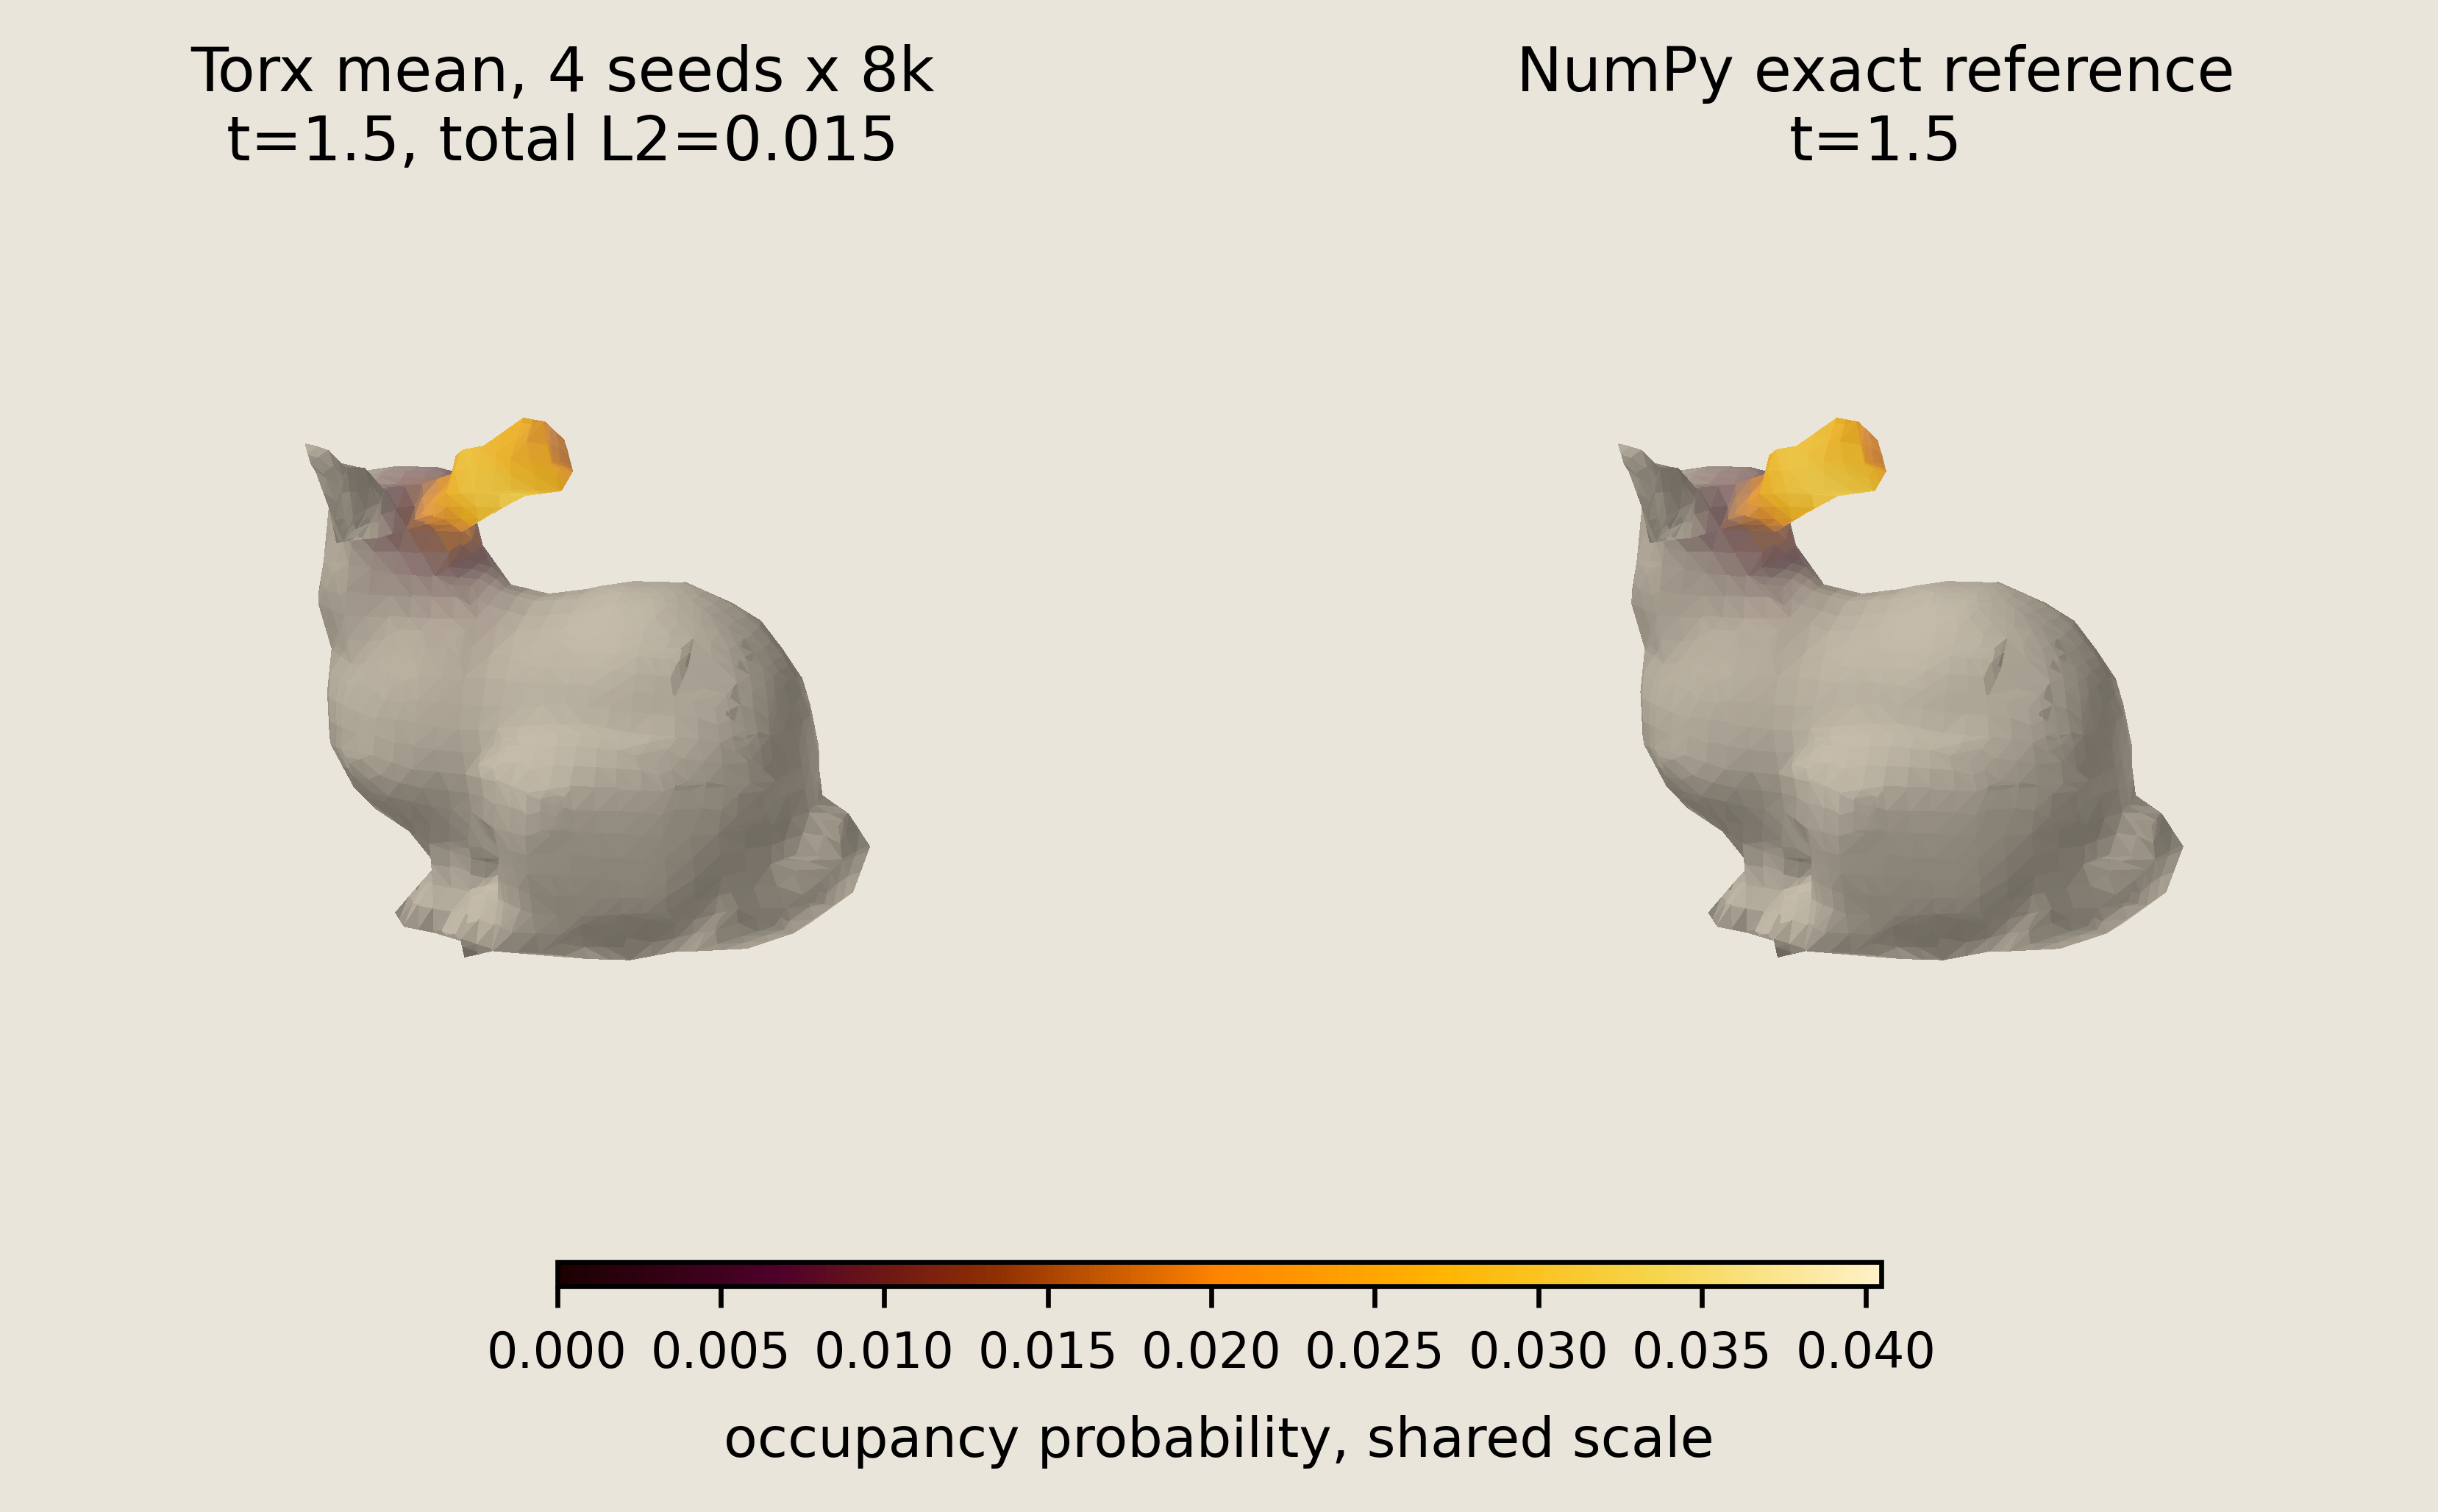

In [14]:
save_torx_reference_figure(
    vertices,
    faces,
    panels=[
        (
            f"Torx mean, {len(TORX_SEEDS)} seeds x {TORX_SAMPLES_PER_SEED // 1000}k\n"
            f"t={TORX_TIME:g}, total L2={total_l2:.3f}",
            torx_field,
        ),
        (f"NumPy exact reference\nt={reference_times[0]:g}", exact_fields[0]),
    ],
    output_stem=FIGURE_DIR / "03_bunny_graph_heat_flow",
    ncols=2,
    normalization="shared",
)

The Torx multi-seed mean is the primary sampled result. The separate distances above compare it with the matching NumPy ordered-sweep mean, then compare that mean with the NumPy exact graph diffusion.

The NumPy exact time progression is easier to read as a left-to-right row.

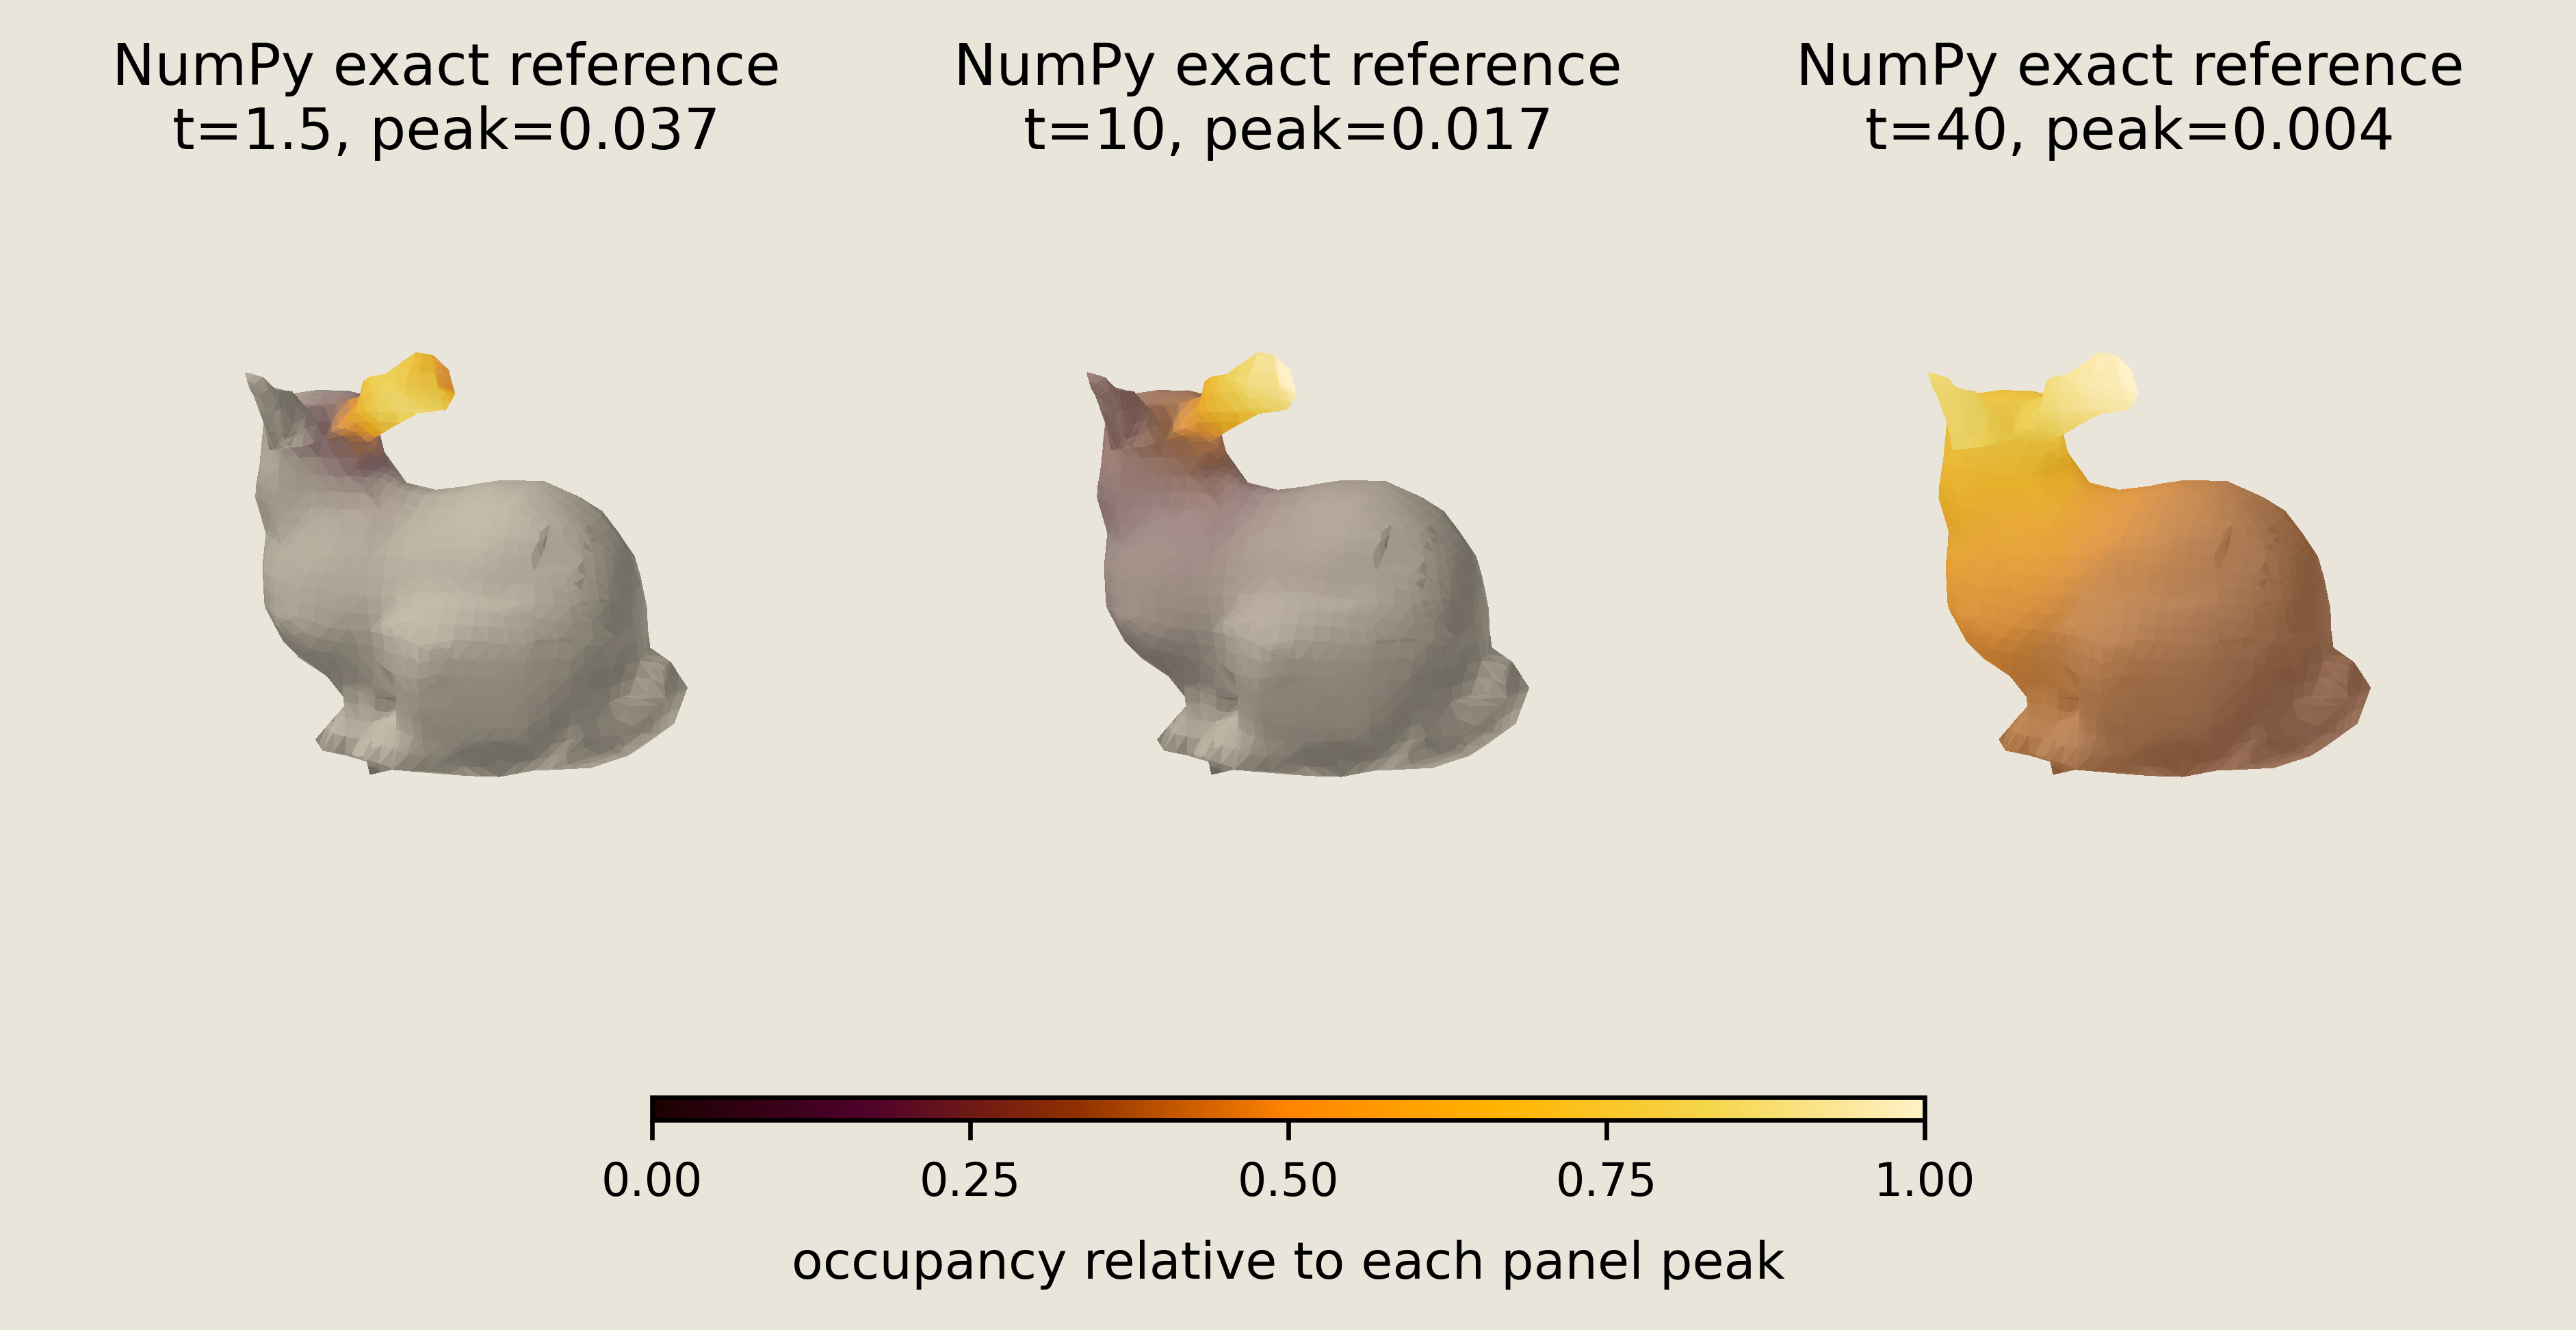

In [15]:
save_torx_reference_figure(
    vertices,
    faces,
    panels=[
        (
            f"NumPy exact reference\nt={t:g}, peak={field.max():.3f}",
            field,
        )
        for t, field in zip(reference_times, exact_fields, strict=True)
    ],
    output_stem=FIGURE_DIR / "03_bunny_reference_diffusion",
    ncols=3,
    normalization="per-panel",
)

The progression uses a separate relative scale in each panel. By $t=40$, the NumPy exact distribution is close to uniform across the connected graph, not a localized front.

## The same Torx primitive, checked on a patch

Every mesh edge contributes exactly one `PSWAP`, identical to [notebook 02](02_random_walks_on_graphs.ipynb). The full circuit has 1,352 gates per repetition, so the figure below shows the primitive on one edge.

The structural two-pbit circuit carries the sites. Its parameter is the logit of $p$, where identity occurs with probability $1-p$ and the states $10$ and $01$ swap with probability $p$.

In [16]:
example_pswap = DiscretePCircuit([PSWAP([0, 1])])

Here is the single-edge gate.

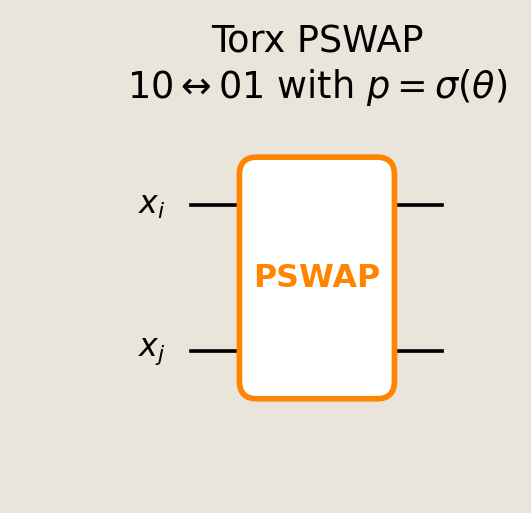

In [17]:
fig = P_sch.draw_edge_pswap(example_pswap)
savefig(fig, "03_bunny_pswap_circuit")

This is the Torx gate repeated once per graph edge in each ordered layer. The full construction and repetition count remain visible above.

We compare Torx with the NumPy deterministic mean of the same ordered sweep on a 32-vertex breadth-first search (BFS) patch.

The patch is a closed induced graph: edges from its 32 vertices to the rest of the bunny are removed. It is an implementation-parity check, not a cropped approximation to the full-graph field.

We use swap probability `0.12` for three repetitions. The code below converts it back to the equivalent unit-rate slice time and prints the patch's effective total time, which is distinct from the full-graph $t=1.5$ result.

In [18]:
PATCH_SIZE = 32
SWAP_PROBABILITY = 0.12
PATCH_REPS = 3
PATCH_SAMPLES = 4_000
PATCH_SEED = 17
PATCH_SLICE_TIME = -0.5 * np.log(1.0 - 2.0 * SWAP_PROBABILITY)
PATCH_EFFECTIVE_TIME = PATCH_REPS * PATCH_SLICE_TIME


In [19]:
# BFS from source to extract a connected patch.
adjacency = [[] for _ in range(len(vertices))]
for a, b in edges:
    adjacency[int(a)].append(int(b))
    adjacency[int(b)].append(int(a))



In [20]:
seen = {int(source)}
queue = deque([int(source)])
while queue and len(seen) < PATCH_SIZE:
    node = queue.popleft()
    for neighbor in sorted(adjacency[node]):
        if neighbor not in seen:
            seen.add(neighbor)
            queue.append(neighbor)
            if len(seen) >= PATCH_SIZE:
                break



In [21]:
patch_vertices = sorted(seen)
patch_index = {old: new for new, old in enumerate(patch_vertices)}
patch_edges = np.asarray(
    [
        (patch_index[int(a)], patch_index[int(b)])
        for a, b in edges
        if int(a) in patch_index and int(b) in patch_index
    ],
    dtype=np.int32,
)
ordered_patch_edges = tuple((int(a), int(b)) for a, b in patch_edges)



In [22]:
print(
    f"closed patch: {len(patch_vertices)} vertices, "
    f"{len(ordered_patch_edges)} internal edges, {PATCH_REPS} reps"
)
print(f"swap probability per edge: {SWAP_PROBABILITY}")
print(f"unit-rate effective time: {PATCH_EFFECTIVE_TIME:.3f}")

closed patch: 32 vertices, 84 internal edges, 3 reps
swap probability per edge: 0.12
unit-rate effective time: 0.412


The NumPy patch reference uses `ordered_pswap_product_formula_mean` from `examples/helpers/_graph_diffusion.py`. It consumes the same `ordered_patch_edges`, repetitions, and swap probability as the Torx circuit.

In [23]:
# The shared helper is also used for the deterministic full-graph mean above.

In [24]:
patch_initial = np.zeros(len(patch_vertices), dtype=float)
patch_initial[patch_index[int(source)]] = 1.0

deterministic_patch = ordered_pswap_product_formula_mean(
    patch_initial,
    ordered_patch_edges,
    reps=PATCH_REPS,
    swap_probability=SWAP_PROBABILITY,
)

The `sample_pswap_product_formula` helper builds the matching ordered Torx `PSWAP` circuit and estimates each vertex occupancy.

In [25]:
torx_patch = sample_pswap_product_formula(
    patch_initial,
    ordered_patch_edges,
    reps=PATCH_REPS,
    swap_probability=SWAP_PROBABILITY,
    num_samples=PATCH_SAMPLES,
    seed=PATCH_SEED,
)
patch_l2 = float(np.linalg.norm(torx_patch - deterministic_patch))

print(f"Torx vs NumPy ordered-sweep mean L2 error: {patch_l2:.4f}")

Torx vs NumPy ordered-sweep mean L2 error: 0.0159


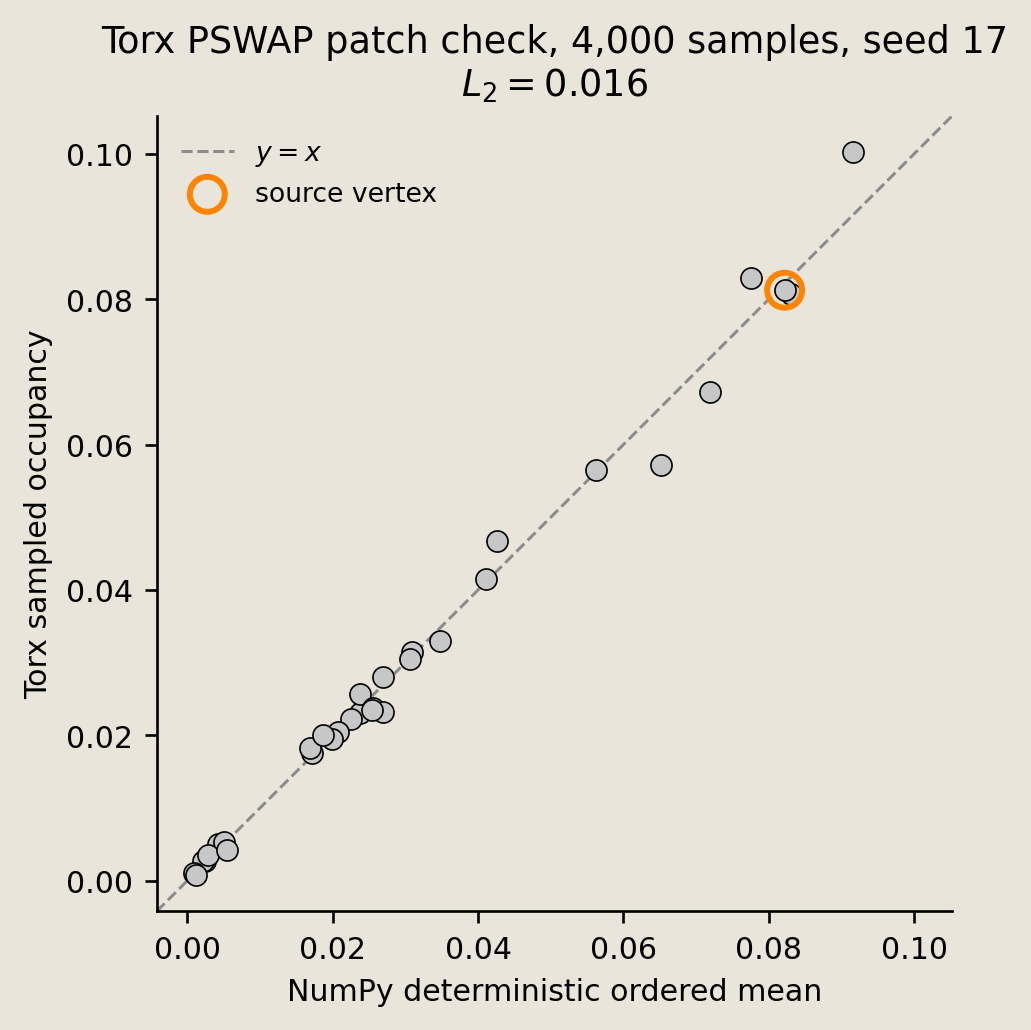

In [26]:
np.testing.assert_allclose(torx_patch.sum(), 1.0, atol=5e-3)

source_local = patch_index[int(source)]
fig = P_samp.patch_parity_figure(
    deterministic_patch,
    torx_patch,
    source_index=source_local,
    l2_error=patch_l2,
    num_samples=PATCH_SAMPLES,
    seed=PATCH_SEED,
)
savefig(fig, "03_bunny_torx_patch_check")

The scatter compares one seeded Torx run with the NumPy deterministic mean of the same closed-patch circuit. The orange ring marks the source vertex.

## Conclusion

We applied Torx graph diffusion to the Stanford bunny's unweighted mesh connectivity.

- The decimated mesh defines a 450-vertex, 1,352-edge graph. It is not a geometry-aware physical heat model.
- Torx executes one `PSWAP` per edge for 11 repetitions and supplies the primary multi-seed sampled result at $t=1.5$.
- NumPy supplies the deterministic ordered-sweep mean, the exact eigensolution, all error metrics, and the $t=10$ and $t=40$ references.
- The full-graph error report separates sampling error, splitting bias, and total error by computing the missing ordered-sweep mean.
- The closed 32-vertex patch checks one seeded Torx run against the matching NumPy ordered mean at its own effective time.

See also:

- [Notebook 02](02_random_walks_on_graphs.ipynb), the same construction on small graphs.
- [Notebook 04](04_execution_interface_readouts.ipynb), how `SampleSimulator` turns a circuit into samples.

## References

1. <span id="ref-trotter-1959"></span>Trotter, H.F. 1959. [*On the product of semi-groups of operators*](https://doi.org/10.1090/S0002-9939-1959-0108732-6). Proc. Amer. Math. Soc. 10(4), 545-551. The ordered per-edge product formula used here.
2. <span id="ref-stanford-bunny"></span>Stanford Computer Graphics Laboratory. [*Stanford Bunny, zipper reconstruction*](https://graphics.stanford.edu/pub/3Dscanrep/bunny.tar.gz), file `bun_zipper_res3.ply`. Distributed through the [Stanford 3D Scanning Repository](https://graphics.stanford.edu/data/3Dscanrep/), which requests source acknowledgment.
